# Incremental Capstone 13 - Natural Language Processing

The objective of this capstone is to analyze reviews, extract insights, and understand sentiment.</br>
</br>
IMDB receives thousands of customer reviews and feedback. However, manually analyzing this data is inefficient. </br>
The goal of this capstone is to develop an NLP-powered sentiment analysis system that automatically classifies </br>
reviews as positive or negative.

## Setup

### Imports

In [1]:
import os
import time
import nltk
import pandas as pd
import numpy as np
from itertools import product

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Dense, GRU, Dropout, Bidirectional, SpatialDropout1D,
    Conv1D, MaxPooling1D, BatchNormalization, LSTM, SimpleRNN
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC

from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay,
    classification_report, precision_score, recall_score, f1_score, roc_auc_score
)

import textwrap
from collections import Counter
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, movie_reviews
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from gensim.models import Word2Vec
from wordcloud import WordCloud
from bs4 import BeautifulSoup
from spellchecker import SpellChecker

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

True

#### Track Notebook Runtime Performance ####

In [2]:
# For Tracking Notebook runtime/performance
notebook_start_time = time.time()

### Configuration

In [3]:
# GloVe download settings
# Keep this, we might use GloVe if time permits
# glove_dir = '../data'
# glove_url = 'https://nlp.stanford.edu/data/glove.twitter.27B.zip'

# Download NLTK resources
nltk.download('stopwords', quiet=True)

# Set up stop words and tokenizer
stop_words = set(stopwords.words('english'))

# Force CPU only
tf.config.set_visible_devices([], 'GPU')

### EDA Utility Functions
These utility/support methods will eventually be pushed into a private support library.

In [4]:
data_set_name = ''
target_label = ''

def WrapText(text, max_width=15):
    """Wrap text to multiple lines"""
    words = str(text).split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= max_width:
            current_line = (current_line + " " + word).strip()
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

def DisplayTable(df_target, table_title=None, max_cell_length=30, show_index=False, 
                 wrap_headers=True, header_wrap_width=15, min_height=3,
                 row_height=0.35, font_size=10):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape
    
    # Adjust columns if showing index
    if show_index:
        n_cols += 1

    # Calculate width based on longest column name or cell content
    col_widths = []
    for col in df_target.columns:
        if wrap_headers:
            max_len = max(len(line) for line in WrapText(col, header_wrap_width).split('\n'))
        else:
            max_len = len(str(col))
        for val in df_target[col]:
            val_len = len(f"{val:.2f}" if isinstance(val, float) else str(val))
            max_len = max(max_len, val_len)
        col_widths.append(min(max_len, max_cell_length))
    
    # Dynamic figure width based on content
    fig_width = max(sum(col_widths) * 0.15, n_cols * 2.0)
    
    # Calculate extra height for wrapped headers
    if wrap_headers:
        max_header_lines = max(len(WrapText(col, header_wrap_width).split('\n')) for col in df_target.columns)
    else:
        max_header_lines = 1
    
    fig_height = (n_rows + max_header_lines) * row_height
    if table_title:
        fig_height += 0.4
    
    # Ensure minimum height for small tables
    fig_height = max(fig_height, min_height)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for idx, row in zip(df_target.index, df_target.values):
        new_row = []
        
        # Add index as first column if show_index
        if show_index:
            s = str(idx)
            if len(s) > max_cell_length:
                s = s[:max_cell_length - 3] + '...'
            new_row.append(s)
        
        for val in row:
            if isinstance(val, (float)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    # Build column labels (with wrapping)
    if show_index:
        col_labels = [df_target.index.name or '']
        if wrap_headers:
            col_labels += [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels += list(df_target.columns)
    else:
        if wrap_headers:
            col_labels = [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels = list(df_target.columns)

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Style data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            if show_index and col == 0:
                table[(row, col)].set_facecolor('#b8d4e8')
                table[(row, col)].set_text_props(fontweight='bold')
            else:
                table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    print()
    print()
    
def PrintDataFrameStatistics(df_target, display_table=True):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Do we have any features empty strings?:')
    print((df_target == "").any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=20)
    print(df_target.sample(20))
    print()

    #
    # Display Results in Pretty Tables
    #
    if display_table == True:
        print('Display Analysis Results in Tables')
        DisplayTable(df_stats, f'{data_set_name} Description Statistics')
        print()
        DisplayTable(df_info, f'{data_set_name} Basic Information')
        print()
        DisplayTable(df_shape, f'{data_set_name} Dataset Shape')
        print()
        DisplayTable(df_missing, f'{data_set_name} Missing Categorical (String) Data')
        print()
        DisplayTable(df_nan, f'{data_set_name} Missing Numeric Data')
        print()
        DisplayTable(df_missingfeature_rowcounts, f'{data_set_name} Summary of Missing Feature Row Counts')
        print()    
        DisplayTable(df_randomsample, f'{data_set_name} Random Data Sample')
        
    print()

## **1.0 Examining Sample Data from the Labeled Review Dataset** ##
## Text Preprocessing  ##

### 1.1 Tokenization
Tokenization splits text into individual units (tokens) such as words or sentences.</br>
NLTK [word_tokenize](https://www.nltk.org/api/nltk.tokenize.html) documentation
</br>
For starters, let's tokenize and have a look at a sample (first 500 characters of the first review [0])</br>
This is just a way to get a feel for how these methods work, what they do and what the data generally looks like.</br>
</br>
Initial examination showed that there were embedded html tokens in the review text; mostly "**</br>**" (line breaks).</br>
We could deal with the embedded html in 1 of 2 methods:
- Regular Expressions
- Using the BeautifulSoup library (which I found thru research) 
</br>
In the spirit of learning new things, I chose "BeautifulSoup"

In [5]:
df_labeledMovieReviews = pd.read_csv('../../../data/Capstone13/labeledTrainData.tsv', sep='\t')
df_unlabeledTestReviews = pd.read_csv('../../../data/Capstone13/unlabeledTestData.tsv', sep='\t')
df_labeledMovieReviews_Original = df_labeledMovieReviews.copy(deep=True)

#PrintDataFrameStatistics(df_labeledMovieReviews)
print(df_labeledMovieReviews.columns)

# Sample text for initial investigation
sample_text = df_labeledMovieReviews['review'].iloc[0][:500]

#print(type(sample_text))
print(f'Original text:\n{sample_text}\n')

# Remove HTML tags
sample_text = BeautifulSoup(sample_text, 'html.parser').get_text()
print(f'Text After HTML tags removed:\n{sample_text}\n')

# Word tokenization
word_tokens = word_tokenize(sample_text)
print(type(word_tokens))

# Sentence tokenization
sent_tokens = sent_tokenize(sample_text)

print(f'Word tokens ({len(word_tokens)} tokens):\n{word_tokens[:20]}...\n')
print(f'Sentence tokens ({len(sent_tokens)} sentences):\n{sent_tokens[:2]}')

Index(['id', 'sentiment', 'review'], dtype='object')
Original text:
With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messa

Text After HTML tags removed:
With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film whic

### 1.2. Normalization and Cleaning

Text normalization includes lowercasing, removing punctuation, and filtering stopwords.

In [6]:
# Lowercase
tokens_lower = [token.lower() for token in word_tokens]

# Remove non-alphabetic tokens
tokens_alpha = [token for token in tokens_lower if token.isalpha()]

# Remove stopwords
stop_words = set(stopwords.words('english'))
tokens_clean = [token for token in tokens_alpha if token not in stop_words]

print(f'Original tokens: {len(word_tokens)}')
print(f'After lowercasing: {len(tokens_lower)}')
print(f'After removing non-alpha: {len(tokens_alpha)}')
print(f'After removing stopwords: {len(tokens_clean)}')
print(f'\nCleaned tokens:\n{tokens_clean[:15]}')

Original tokens: 99
After lowercasing: 99
After removing non-alpha: 92
After removing stopwords: 44

Cleaned tokens:
['stuff', 'going', 'moment', 'mj', 'started', 'listening', 'music', 'watching', 'odd', 'documentary', 'watched', 'wiz', 'watched', 'moonwalker', 'maybe']


### 1.3 Stemming and Lemmatization

Stemming reduces words to their root form by removing suffixes. Lemmatization reduces words to their dictionary form (lemma).

NLTK [PorterStemmer](https://www.nltk.org/api/nltk.stem.porter.html) and [WordNetLemmatizer](https://www.nltk.org/api/nltk.stem.wordnet.html) documentation

In [7]:
# Stemming
stemmer = PorterStemmer()
tokens_stemmed = [stemmer.stem(token) for token in tokens_clean]

# Lemmatization
lemmatizer = WordNetLemmatizer()
tokens_lemmatized = [lemmatizer.lemmatize(token) for token in tokens_clean]

# Compare results
comparison_df = pd.DataFrame({
    'original': tokens_clean[:50],
    'stemmed': tokens_stemmed[:50],
    'lemmatized': tokens_lemmatized[:50]
})

comparison_df

,original,stemmed,lemmatized
0,stuff,stuff,stuff
1,going,go,going
2,moment,moment,moment
3,mj,mj,mj
4,started,start,started
5,listening,listen,listening
6,music,music,music
7,watching,watch,watching
8,odd,odd,odd
9,documentary,documentari,documentary


### 1.2 Normalization and cleaning of Sample Data

Text normalization includes lowercasing, removing punctuation, and filtering stopwords.

In [8]:
# Lowercase
tokens_lower = [token.lower() for token in word_tokens]

# Remove non-alphabetic tokens
tokens_alpha = [token for token in tokens_lower if token.isalpha()]

# Remove stopwords
stop_words = set(stopwords.words('english'))

# Initially, I just handled this by adding 'br' to stopwords, but that really
# doesn't address issue. Needed to preprocess all embedded <HTML> tags from text
# This is now done in a previous sell using BeautifulSoup()
# To handle embedded html linebreaks
#stop_words.add('br')

tokens_clean = [token for token in tokens_alpha if token not in stop_words]

print(f'Original tokens: {len(word_tokens)}')
print(f'After lowercasing: {len(tokens_lower)}')
print(f'After removing non-alpha: {len(tokens_alpha)}')
print(f'After removing stopwords: {len(tokens_clean)}')
print(f'\nCleaned tokens:\n{tokens_clean[:15]}')

Original tokens: 99
After lowercasing: 99
After removing non-alpha: 92
After removing stopwords: 44

Cleaned tokens:
['stuff', 'going', 'moment', 'mj', 'started', 'listening', 'music', 'watching', 'odd', 'documentary', 'watched', 'wiz', 'watched', 'moonwalker', 'maybe']


## **2.0 Text Exploration - The Labeled Review Dataset** ##
## 2.1 Word Frequency Analysis ##
Word frequency analysis across entire corpus.</br>
BeautifulSoup added to preprocess_text() to remove 'HTML' tags from each review</br>
Slows preprocessing down, but more accurate than relying on RegEx()</br>

In [9]:
# Preprocess function for full corpus
def preprocess_text(text):

    # Probably more efficient way to do this, but this isn't a programming class.
    clean_text = BeautifulSoup(text, 'html.parser').get_text()

    tokens = word_tokenize(clean_text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return tokens

# Get all tokens from corpus
all_tokens = []

for text in df_labeledMovieReviews['review']:
    all_tokens.extend(preprocess_text(text))

# Count word frequencies
word_freq = Counter(all_tokens)
top_20 = word_freq.most_common(20)

# The number of unique words in the Dataset
print("Number of unique words across all the reviews")
print(f"Unique Words: {len(word_freq)}")

# Display top words
freq_df = pd.DataFrame(top_20, columns=['word', 'count'])
print("Top 20 most frequent words")
freq_df

Number of unique words across all the reviews
Unique Words: 71024
Top 20 most frequent words


,word,count
0,movie,42345
1,film,38611
2,one,25506
3,like,19643
4,good,14464
5,would,13374
6,even,12447
7,time,11828
8,really,11672
9,story,11443


#### Word Frequency Analysis and Observations
Initially, I noticed there is a high frequency of the token "**br**"</br>
Upon further examination of the original data set this because html linebreaks are embedded in the reviews.</br>
This was be cleaned up as it could/will skew any training/predictions we do.</br>
</br>

#### Identify the Unknown Words
I would like to examine the entire corpus and identify any unknown/unrecognized words and their frequency. </br>
Some of these words might be slangs, some might be legitimate misspellings. </br>
With 70K-ish tokens this shouldn't be a heavy lift.</br>
Once examining the results, I can make a strategy (if any) to deal with unknown/misspelled words.</br>
We're not going to worry about punctuation correctness as punctuation will get filtered out through pre-processing. </br>
</br>
Surprisingly, there are over 26K unknown words in the tokens.</br>
Before deciding whether or not I'm just chasing down a potential rabbit hole, examine the following:</br>
- Most common unknown words
- Middle common unknown words
- Least common unknown words


In [10]:
spell_checker = SpellChecker()

all_unique_words = list(word_freq.keys())
unknown_words = spell_checker.unknown(all_unique_words)
print(f"Number of Unique Unknown Words: {len(unknown_words)}")

# Get frequency of unknown word instances
unknown_freqs = [(word, word_freq[word]) for word in unknown_words]
unknown_freqs.sort(key=lambda x: x[1], reverse=True)

# Words occurring over 100 times
most_common_unknown_words = [item for item in unknown_freqs if item[1] > 100]
print(f"20 most common unknown words (Total {len(most_common_unknown_words)}) ---")
print(most_common_unknown_words[:20])

# Words occurring between 5 and 10 times
middle_used_unknown_words = [item for item in unknown_freqs if 5 <= item[1] <= 10]
print(f"20 most common averagely used unknown words (Total {len(middle_used_unknown_words)}) ---")
print(middle_used_unknown_words[:20])

# Words appearing only once
least_common_unknown_words = [item for item in unknown_freqs if item[1] == 1]
print(f"20 least common unknown words (Total {len(least_common_unknown_words)}) ---")
print(most_common_unknown_words[:20])


Number of Unique Unknown Words: 26174
20 most common unknown words (Total 55) ---
[('tv', 2507), ('dvd', 2217), ('etc', 985), ('imdb', 638), ('humour', 426), ('thats', 341), ('noir', 338), ('favourite', 324), ('ii', 309), ('cgi', 309), ('vhs', 269), ('gon', 242), ('uk', 215), ('fu', 198), ('columbo', 183), ('von', 178), ('branagh', 176), ('sandler', 167), ('bbc', 166), ('kung', 163)]
20 most common averagely used unknown words (Total 2197) ---
[('gundams', 10), ('driscoll', 10), ('liang', 10), ('warburton', 10), ('rajni', 10), ('capano', 10), ('nudie', 10), ('spectre', 10), ('mariette', 10), ('hickcock', 10), ('tatooine', 10), ('brimley', 10), ('rad', 10), ('henstridge', 10), ('ke', 10), ('schell', 10), ('ther', 10), ('munchie', 10), ('forlani', 10), ('amityville', 10)]
20 least common unknown words (Total 16178) ---
[('tv', 2507), ('dvd', 2217), ('etc', 985), ('imdb', 638), ('humour', 426), ('thats', 341), ('noir', 338), ('favourite', 324), ('ii', 309), ('cgi', 309), ('vhs', 269), ('g

#### Unique Word Discovery Analysis
I took a quick look at a sampling of the most, average, least number of unknown words.</br>
Based on the output, it looks like all of these are legitimate words coming under the following types:
- slangs
- acronyms 
- abbreviations
- proper names</br>

</br>
Based on that, we can keep the unknown words as part of the overall tokenized corpus as they do carry weight/meaning in the review.


#### Examination of Review Lengths

Review Length Analysis Results

Average Review Length: 1327.71
Average Word Count per Review: 233.79



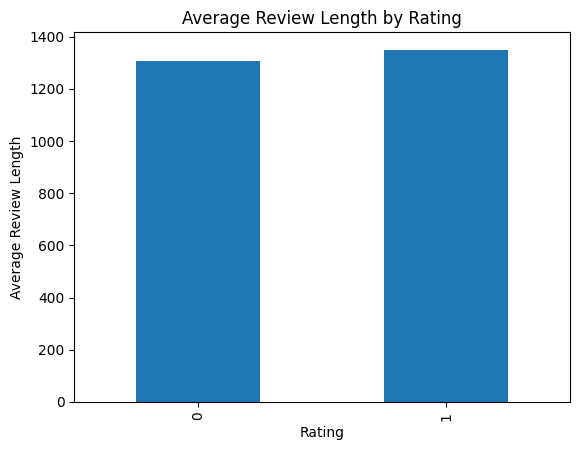

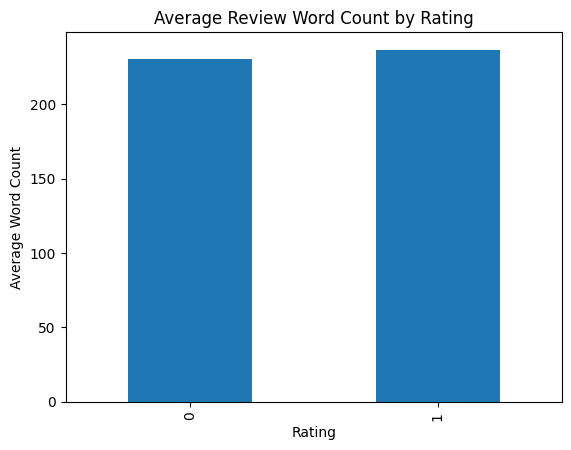

In [11]:
# Average character length of a review
average_review_length = df_labeledMovieReviews['review'].str.len().mean()

# Calculate average number of words per review
average_review_word_count = df_labeledMovieReviews['review'].str.split().str.len().mean()

print('============================================================================')
print('Review Length Analysis Results')
print()
print(f'Average Review Length: {average_review_length:.2f}')
print(f'Average Word Count per Review: {average_review_word_count:.2f}')
print()
print('============================================================================')


df_reviewLength = df_labeledMovieReviews.copy(deep=True)
df_reviewLength['average_review_length'] = average_review_length
df_reviewLength['average_review_word_count'] = average_review_word_count

df_labeledMovieReviews.groupby('sentiment')['review'].apply(
                                                                lambda x: x.str.len().mean()
                                                            ).plot(kind='bar')
plt.title('Average Review Length by Rating')
plt.ylabel('Average Review Length')
plt.xlabel('Rating')
plt.show()

df_labeledMovieReviews.groupby('sentiment')['review'].apply(
                                                                lambda x: x.str.split().str.len().mean()
                                                            ).plot(kind='bar')
plt.title('Average Review Word Count by Rating')
plt.ylabel('Average Word Count')
plt.xlabel('Rating')
plt.show()

#### Observations of Review Lengths
Reviews for Negative and Positive sentiments have almost identical average review lengths and word counts.</br>
I'm not sure if that reflects reality or is just a characteristic of this dataset.</br>
I guess that tells the sentiment is not necessarily an indicator of the length of the reviews. </br>
Conversely, a short or long review does not necessarily predict the overall sentiment of the review.</br>

### 2.2 Word Cloud Visualization

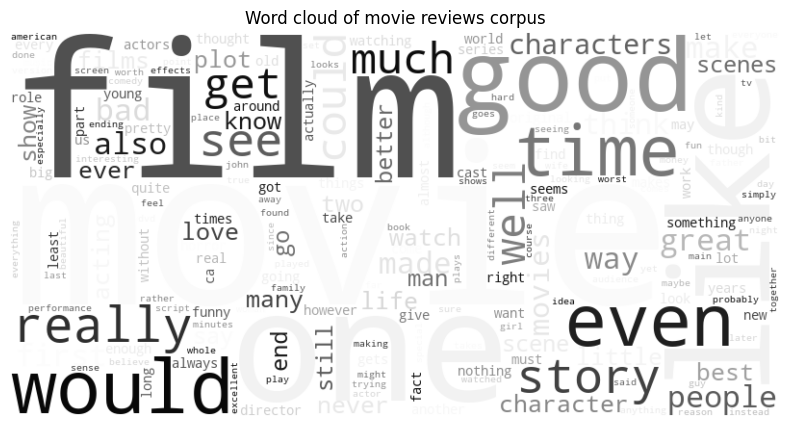

In [12]:
# Create word cloud
wordcloud = WordCloud(
                        width=800,
                        height=400,
                        background_color='white',
                        colormap='Greys'
                    ).generate_from_frequencies(word_freq)

plt.figure(figsize=(10, 5))
plt.title('Word cloud of movie reviews corpus')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### 2.3 Word Frequency Distribution

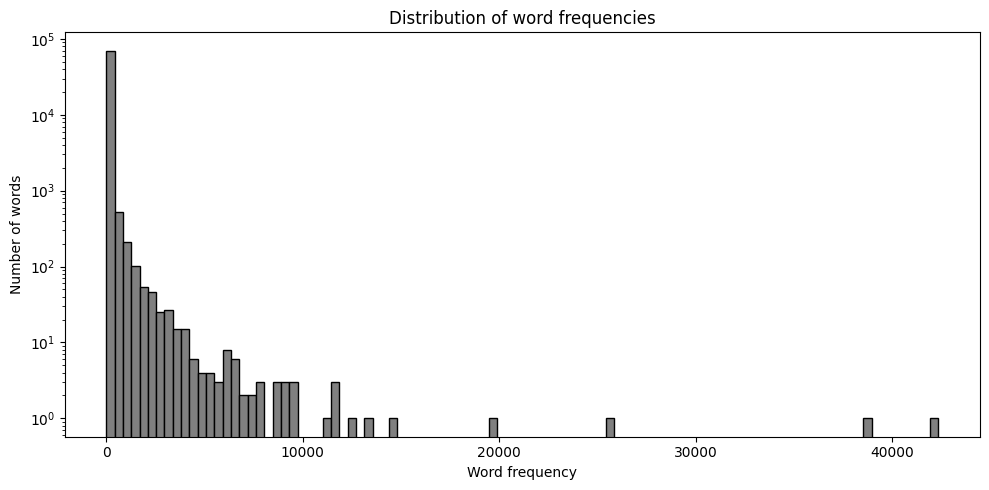

In [13]:
# Histogram of word frequency distribution
word_counts = list(word_freq.values())

plt.figure(figsize=(10, 5))
plt.title('Distribution of word frequencies')
plt.hist(word_counts, bins=100, color='grey', edgecolor='black')
plt.xlabel('Word frequency')
plt.ylabel('Number of words')
plt.yscale('log')  # Use logarithmic scale for better visibility
plt.tight_layout()
plt.show()

#### Word Frequency Observations

## **3.0 Sentiment Analysis** ##
Build sentiment classification models (positive:1 vs negative:0) using the following models:
- Naive Bayes
- Custom LSTM Deep Learning Model
- Pre-trained BERT model from HuggingFace

### 3.1 Naive Bayes Model
This was taken directly from George's Lesson_38_demo notebook.
#### Prepare the data

In [14]:
# Prepare data
X = df_labeledMovieReviews['review']
y = df_labeledMovieReviews['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
                                                        X, y,
                                                        test_size=0.2,
                                                        random_state=315
                                                    )

# Vectorize text using bag-of-words
vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f'Training set: {X_train_vec.shape}')
print(f'Test set: {X_test_vec.shape}')

Training set: (20000, 5000)
Test set: (5000, 5000)


#### Train the Model

In [15]:
# Train Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_vec, y_train)

# Predict and evaluate
y_pred = nb_classifier.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.3f}\n')
print('Classification report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.849

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      2535
           1       0.85      0.84      0.85      2465

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



### 3.2 VADER Sentiment Analyzer
In keep with the tme from Lesson_38_demo, I thought it would be interesting to explore Rules Based Sentiment Analysis thru VADER.</br>
Once again this was pretty much taken verbatim from George's Lesson_38_demo notebook.

****VADER** (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon-based sentiment analyzer that uses a dictionary of words with pre-assigned sentiment scores.</br>
NLTK [VADER](https://www.nltk.org/howto/sentiment.html) documentation </br>

#### Sentiment Analysis for random sample from that the dataset.

In [16]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Take 25 random samples from the train split and run thru VADER 
# just to see how they get ranked (satisfy curiosity)

# Analyze sentiment
print('Movie Review Random Sample VADER sentiment scores:\n')

for index, row in df_labeledMovieReviews.sample(25).iterrows():
    scores = sia.polarity_scores(row['review'])
    print(f'Text: {textwrap.fill(row["review"], width=120)}')
    print()
    print(f'Sentiment: {row["sentiment"]}')
    print(f'Sample #{index+1} Scores: {scores}\n')
    print()

Movie Review Random Sample VADER sentiment scores:

Text: In Iran women are prohibited from attending live sporting events because of the fear that they will be \corrupted\" by
bad language, close proximity to thousands of men, and the fact that there are no toilet facilities for women in the
antiquated stadiums. Based on an actual incident involving the daughter of the director, Jafar Panahi's Offside follows
six girls, disguised as men, who are refused entry into the soccer match in 2005 between Iran and Bahrain, a match that
will decide whether or not Iran goes to the World Cup. In a departure from the bleak, minimalist films we have been
accustomed to from Iran over the last ten years, Offside is an exuberant comedy that has a patriotic fervor and a
universal appeal but contains enough subversive social commentary to warrant its prohibition from screenings in Iran.<br
/><br />Shot with a digital camera using non-professional actors who are more than up to the task, the girls try to

#### Apply Vader to test set and compare with feature label

In [17]:
# Apply VADER to test set
def vader_predict(text):

    scores = sia.polarity_scores(text)
    if scores['compound'] >= 0.05:
        return 1
    elif scores['compound'] <= -0.05:
        return 0
    else:
        return 0  # Default to negative for neutral

# Predict with VADER
y_pred_vader = [vader_predict(text) for text in X_train]
vader_accuracy = accuracy_score(y_train, y_pred_vader)

print(f'VADER accuracy: {vader_accuracy:.3f}')
print(f'Naive Bayes accuracy: {accuracy:.3f}')


VADER accuracy: 0.693
Naive Bayes accuracy: 0.849


#### VADER Analysis
Naive Bayes scored much higher than VADER in terms of Test dataset accuracy.</br>
This expected because **Naives Bayes** is supervised learning while **VADER** is rule based using a dictionary of predefined words and intensity scores. </br>
**Naive Bayes** is a trained model that actually learns, while **VADER** does not.
</br>

### 3.3 Custom Deep Learning model including LSTM layers
Looking at reviews, I thought I'd experiment and play with Sequential Models with a varied number of layers.</br>
Some initial research warned against potential overfitting if applying multi-LSTM layered models against smaller datasets </br>
Giving it some thought.., our dataset isn't necessarily small (maybe in the entire scope of all movie reviews it is...) </br>
The other risk is that I'm only running on a CPU, so it could be pretty slow to process. </br>
Regardless, let's try it out and see what kind fo results we see.

#### Deep Learning (LSTM) Model Creation Functions
I'm going to create 3 distinct DL CNN-LSTM hybridmodels:
- 1 LSTM Layer
- Stacked Models - learn more hierarchical features
    - 2 LSTM Layers  - phrases??
    - 3 LSTM Layers  - sentences ??

Upon building/training and testing the model, I will compare the results to determine the best performing DL model.</br>
I'll use this "**Best of Class**" model in my comparisons with Naive Bayes and the pretrained "Bert" model.


#### Parameter Definitions ####
- **vocab_size** = 25,000
    - Reduce tails/outliers
    - Reduce sparseness of data (sparse matrix)
    - Reduce number of parameters (25K X 300) instead of (75K X 300)
    - Picking 25k most frequent words helps be more compatible with Word2Vec
- **output_dim** = 300
    - Standard vector size originally used on pre-trained Word2Vec
    - Allows for Apples-Apples comparison between **Learned Embedding** and **Word2Vec** models
- **input_length** (review length) = 500 (words)
    - Roughly 2X the average review length (240-ish words)
    - Given average length, ths will capture most of the reviews entirely
    - First 500 words should be enough to get a feeling for the overall climate of a review
    - Have to pad short reviews though

In [18]:
vocab_size = 25000
output_dim = 300
input_length = 500

#### Model Definitions
Create 4 LSTM-CNN hybrid models.
1. Single LSTM Layer - Embedding (dynamically learns while training)
2. 1 LSTM Layer - Word2Vec (static/pretrained)
3. 2 LSTM Layers (Stacked Model) - Word2Vec
4. 3 LSTM Layers (Stacked Model) - Word2Vec </br>


In [19]:
# Definition borrowed from previous capstone.
#
def CreateSingleLayerLTSMModel_Embedding(dropout_rate):
    model = Sequential([

        # Embedding - convert 2D sequences into 3D vectors [required by SimpleRNN(), LTSM()]
        # Words -> Numeric Vectors
        Embedding(vocab_size + 1, output_dim, input_length=input_length),
        
        # Block 1: Convolutional
        # Text is 1 dimensional sequence - so use 1D function layers
        # filters => 32, 64, 128 - powers of 2; 
        # relu activation - Standard (default) starting point for activation function selection
        # Find local patterns/phrases
        Conv1D(filters=64, kernel_size=3, activation='relu'),

        # Normalizes activations
        BatchNormalization(),

        # Reduces Dimensions
        MaxPooling1D(pool_size=2),

        # Randomly drop/turn-off neurons
        Dropout(dropout_rate),
        
        # Block 2: Recurrent
        LSTM(64, return_sequences=False),
        Dropout(dropout_rate),
        
        # Block 3: Dense
        Dense(32, activation='relu'),
        Dropout(dropout_rate),

        # Binary classification: squashes sentiment between 0 or 1
        Dense(1, activation='sigmoid')  
    ])

    return model

# 1 LSTM Layer
def CreateLSTMModel_Word2Vec(dropout_rate, embedding_matrix):
    model = Sequential([

        # Embedding: initialized with Word2Vec weights, frozen (not trainable)
        Embedding(input_dim=vocab_size + 1, 
                  output_dim=output_dim, 
                  input_length=input_length,
                  weights=[embedding_matrix],
                  trainable=False),  # Set True to fine-tune

        # Block 1: Convolutional
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        # Block 2: Recurrent
        LSTM(64, return_sequences=False),
        Dropout(dropout_rate),

        # Block 3: Dense
        Dense(32, activation='relu'),
        Dropout(dropout_rate),

        Dense(1, activation='sigmoid')
    ])

    return model

def CreateLSTMModel_Word2Vec_2LSTM(dropout_rate, embedding_matrix):
    model = Sequential([

        # Embedding: initialized with Word2Vec weights, frozen (not trainable)
        Embedding(input_dim=vocab_size + 1, 
                  output_dim=output_dim, 
                  input_length=input_length,
                  weights=[embedding_matrix],
                  trainable=False),

        # Block 1: Convolutional
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        # Block 2: Recurrent - LSTM 1
        # return_sequences=True required to pass sequence to next LSTM layer
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),

        # Block 3: Recurrent - LSTM 2
        # return_sequences=False - last LSTM collapses sequence to single vector
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),

        # Block 4: Dense
        Dense(32, activation='relu'),
        Dropout(dropout_rate),

        Dense(1, activation='sigmoid')
    ])

    return model

def CreateLSTMModel_Word2Vec_2LSTM(dropout_rate, embedding_matrix):
    model = Sequential([

        # Embedding: initialized with Word2Vec weights, frozen (not trainable)
        Embedding(input_dim=vocab_size + 1, 
                  output_dim=output_dim, 
                  input_length=input_length,
                  weights=[embedding_matrix],
                  trainable=False),

        # Block 1: Convolutional
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        # Block 2: Recurrent - LSTM 1
        # return_sequences=True required to pass sequence to next LSTM layer
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),

        # Block 3: Recurrent - LSTM 2
        # return_sequences=False - last LSTM collapses sequence to single vector
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),

        # Block 4: Dense
        Dense(32, activation='relu'),
        Dropout(dropout_rate),

        Dense(1, activation='sigmoid')
    ])

    return model

def CreateLSTMModel_Word2Vec_3LSTM(dropout_rate, embedding_matrix):
    model = Sequential([

        # Embedding: initialized with Word2Vec weights, frozen (not trainable)
        Embedding(input_dim=vocab_size + 1, 
                  output_dim=output_dim, 
                  input_length=input_length,
                  weights=[embedding_matrix],
                  trainable=False),

        # Block 1: Convolutional
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        # Block 2: Recurrent - LSTM 1
        LSTM(128, return_sequences=True),
        Dropout(dropout_rate),

        # Block 3: Recurrent - LSTM 2
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),

        # Block 4: Recurrent - LSTM 3
        # Last LSTM collapses sequence to single vector
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),

        # Block 5: Dense
        Dense(32, activation='relu'),
        Dropout(dropout_rate),

        Dense(1, activation='sigmoid')
    ])

    return model



#### Preprocess Text Review Data
Apply texting preprocessing and lemmatization before building/processing DL models.
Choosing lemmatization over stemming because I prefer more accurate - dictionary-ish approach.

In [20]:
lemmatizer = WordNetLemmatizer() 

# Preprocess function for full corpus
def preprocess_text_for_lstm(text):
    clean_text = BeautifulSoup(text, 'html.parser').get_text()
    tokens = word_tokenize(clean_text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    
    # Lemmatize each token
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return tokens

#### Final Text Preprocessing and Test/Train Split #####
Now we are at the point of preparing the data for actual model training.</br>
The final preparation included the following steps:
1. Text Preprocessing
    - Preprocess (text) the entire corpus before completing the required splits.
2. Train/Test Splits
    - i) Initial 80/20 Train/Test split of entire dataset
    - ii) Split Train dataset 80/20 into Train/Validation datasets
3. Tokenization
    - Tokenize the split datasets into tokens for consumption by models
4. Pad Sequences
    - Pad the tokenized datasets to max length so they are all equal length (better for model performance)

</br>
**Note:** I was trying to be cognizant of potential data leakage during these steps

In [21]:
# Preprocess ENTIRE Dataset 
debug_datasample_size = None
df_labeledMovieReviews['tokens'] = df_labeledMovieReviews['review'].apply(
    lambda x: ' '.join(preprocess_text_for_lstm(x))
)


#################################################################################################
# # For testing/debugging purposes, take just 100 rows
# debug_datasample_size = 5
# df_labeledMovieReviews['tokens'] = df_labeledMovieReviews['review'].head(5).apply(
#     lambda x: ' '.join(preprocess_text_for_lstm(x))
# )
# # Drop rows where tokens were not assigned (rows 101-25000)
# df_labeledMovieReviews = df_labeledMovieReviews.dropna(subset=['tokens'])  
#################################################################################################

# for text in df_labeledMovieReviews['review']:
#     all_tokens.extend(preprocess_text_for_lstm(text))

# Extract X and y
X_raw = df_labeledMovieReviews['tokens'].values
y     = df_labeledMovieReviews['sentiment'].values

# Initial Train/Test split into 80/20 split
X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
                                                                    X_raw, 
                                                                    y, 
                                                                    test_size=0.2, 
                                                                    random_state=42
                                                                )

# Split Validation from Train - 80/20 split Train/Validation
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
                                                            X_trainval_raw, 
                                                            y_trainval, 
                                                            test_size=0.2,
                                                            random_state=42
                                                        )

print(f'X_train shape: {len(X_train_raw)}')
print(f'X_val   shape: {len(X_val_raw)}')
print(f'X_test  shape: {len(X_test_raw)}')

# Fit Tokenizer on Train Only (prevents data leakage) ──────────────
tokenizer_tool = Tokenizer(num_words=vocab_size)
tokenizer_tool.fit_on_texts(X_train_raw)

# Tokenize and Pad All 3 Splits - Train, Validation, Test
X_train = pad_sequences(tokenizer_tool.texts_to_sequences(X_train_raw), maxlen=input_length, padding='post')
X_val   = pad_sequences(tokenizer_tool.texts_to_sequences(X_val_raw),   maxlen=input_length, padding='post')
X_test  = pad_sequences(tokenizer_tool.texts_to_sequences(X_test_raw),  maxlen=input_length, padding='post')

X_train shape: 16000
X_val   shape: 4000
X_test  shape: 5000


#### Hyperparameter Definitions

In [22]:
dropout_rates  = [0.2, 0.3, 0.4, 0.5]
learning_rates = [0.001, 0.0001]
batch_sizes    = [32, 64, 128]
thresholds     = [0.3, 0.4, 0.5, 0.6, 0.7]

#### Create Word2Vec Embedding Matrix
Based on Lesson_39_demo

In [23]:
# Create Word2Vec Model
# Parameters based on Lesson_39_demo
w2v_model = Word2Vec(
                        sentences=all_tokens,        # List of tokenized documents
                        vector_size=output_dim,      # Dimensionality of the embedding
                        window=5,                    # Context window size (words before/after target)
                        min_count=5,                 # Minimum word frequency to include in vocabulary
                        seed=315                     # Random seed for reproducibility
                    )

print(f'Vocabulary size: {len(w2v_model.wv)}')

def CreateEmbeddingMatrix(word_index, w2v_model, embedding_dim=300):

    embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))
    
    for word, idx in word_index.items():
        if idx <= vocab_size and word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
    return embedding_matrix

word_index = tokenizer_tool.word_index

embedding_matrix = CreateEmbeddingMatrix(
                                            word_index    = word_index,
                                            w2v_model     = w2v_model,
                                            embedding_dim = output_dim      
                                        )

print(f'Embedding matrix shape: {embedding_matrix.shape}')

Vocabulary size: 51
Embedding matrix shape: (25001, 300)


#### Model Hyperparameter Tuning and Evaluation
Iterate through the hyperparameters to find the best combination for each of the model flavours.</br>
Use validation split to track model performance on "unseen data" during training.</br>
Track and keep a running accumlulator of the results.</br>
Based on f1_scores determine the best weights.</br></br>
Utilize 2 callbacks:
- EarlyStopping
    - Monitor validation loss and stop when model no longer learns/improves
- Checkpoint
    - Save best training weights in event of failure/system crash

In [24]:
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.metrics import Precision, Recall, AUC
# from sklearn.metrics import (
#     confusion_matrix, roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay,
#     classification_report, precision_score, recall_score, f1_score, roc_auc_score
# )
# debug_datasample_size = 5

def TuneAndEvaluateModel(model_name, create_model_fn, model_fn_args,
                          X_train, y_train, X_val, y_val, X_test, y_test,
                          dropout_rates, learning_rates, batch_sizes, thresholds,
                          epochs=10):

    print('=================================================================================================')
    print(f'Evaluating Model: {model_name}')

    total_combinations = len(dropout_rates) * len(learning_rates) * len(batch_sizes) * len(thresholds)
    print(f'Total hyperparameter combinations: {total_combinations}')

    # Callbacks
    checkpoint_path = f'models/checkpoint_{model_name}.weights.h5'

    # Using patience of 7 as a 'happy medium' - not too conservative or aggressive
    early_stopping = EarlyStopping(
                                    monitor='val_loss',
                                    patience=7,
                                    restore_best_weights=True
                                )

    # Trying to use rolling checkpoint as precaution/fallback protection against model crashes
    checkpoint = ModelCheckpoint(
                                    filepath=checkpoint_path,
                                    monitor='val_loss',
                                    save_best_only=True,
                                    save_weights_only=True,
                                    verbose=1
                                )

    tuning_results = []
    combo_num      = 0
    best_val_f1    = -1         # -1 guarantees first combo always sets best_result
    best_result    = None
    best_weights   = None

    for dropout_rate, learning_rate, batch_size in product(dropout_rates, learning_rates, batch_sizes):

        # Build the model
        model = create_model_fn(dropout_rate, **model_fn_args)

        # Compile the model with varied learning_rate
        # Adam optimizer adjusts learning rates for each parameter
        # (More efficient)
        model.compile(
                        optimizer=Adam(learning_rate=learning_rate),
                        loss='binary_crossentropy',
                        metrics=[
                                    'accuracy',
                                    Precision(name='precision'),
                                    Recall(name='recall'),
                                    AUC(name='auc')
                                ]
                    )

        #model.summary()

        history = model.fit(
                            X_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_data=(X_val, y_val),
                            callbacks=[early_stopping, checkpoint],
                            verbose=1
                        )

        # Final epoch loss values from history
        final_loss     = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]

        # Get raw probabilities once — reuse for all thresholds
        val_probs = model.predict(X_val)

        for threshold in thresholds:

            combo_num += 1
            print(f'Combo {combo_num} dropout={dropout_rate} learning_rate={learning_rate} batch={batch_size} threshold={threshold}')

            y_pred_val = (val_probs > threshold).astype(int)
            val_f1     = f1_score(y_val, y_pred_val, zero_division=0)

            # Accumulate a running collection of results
            # zero_division=0 gets rid of undefined metric warning
            tuning_results.append({
                                    'model_name':    model_name,
                                    'run':           combo_num,
                                    'dropout_rate':  dropout_rate,
                                    'learning_rate': learning_rate,
                                    'batch_size':    batch_size,
                                    'threshold':     threshold,
                                    'loss':          final_loss,
                                    'val_loss':      final_val_loss,
                                    'val_accuracy':  accuracy_score(y_val,  y_pred_val),
                                    'val_precision': precision_score(y_val, y_pred_val, zero_division=0),
                                    'val_recall':    recall_score(y_val,    y_pred_val, zero_division=0),
                                    'val_f1':        val_f1,
                                })

            # If f1_score improves, we've got a new best model
            if val_f1 > best_val_f1:

                best_val_f1 = val_f1
                best_result = {
                                'model_name':    model_name,
                                'best_run':      combo_num,
                                'dropout_rate':  dropout_rate,
                                'learning_rate': learning_rate,
                                'batch_size':    batch_size,
                                'threshold':     threshold,
                                'loss':          final_loss,
                                'val_loss':      final_val_loss,
                                'val_accuracy':  accuracy_score(y_val,  y_pred_val),
                                'val_precision': precision_score(y_val, y_pred_val, zero_division=0),
                                'val_recall':    recall_score(y_val,    y_pred_val, zero_division=0),
                                'val_f1':        val_f1,
                            }
                best_weights = model.get_weights()
                print(f'  *** New best — Run {combo_num} — '
                      f'F1: {val_f1:.4f}  threshold: {threshold} ***')

    # Best Hyperparameters Summary
    df_tuning = pd.DataFrame(tuning_results)
    print(f'======================================================================')
    print(f'{model_name} Tuning Results')
    print(f'======================================================================')
    print(df_tuning.sort_values('val_f1', ascending=False).to_string())

    print(f'======================================================================')
    print(f'{model_name} Best Hyperparameters')
    print(f'======================================================================')
    print(f'Best Run      : {best_result["best_run"]} of {total_combinations}')
    print(f'dropout_rate  : {best_result["dropout_rate"]}')
    print(f'learning_rate : {best_result["learning_rate"]}')
    print(f'batch_size    : {best_result["batch_size"]}')
    print(f'threshold     : {best_result["threshold"]}')
    print(f'Loss          : {best_result["loss"]:.4f}')
    print(f'Val Loss      : {best_result["val_loss"]:.4f}')
    print(f'Validation F1 : {best_result["val_f1"]:.4f}')
    print(f'Checkpoint    : {checkpoint_path}')
    print()

    # Restore Model with Best Weights
    best_model = create_model_fn(best_result['dropout_rate'], **model_fn_args)
    best_model.compile(
                        optimizer=Adam(learning_rate=best_result['learning_rate']),
                        loss='binary_crossentropy',
                        metrics=[
                                    'accuracy',
                                    Precision(name='precision'),
                                    Recall(name='recall'),
                                    AUC(name='auc')
                                ]
                    )

    # Build the model by passing one sample through before setting weights
    best_model.predict(X_train[:1], verbose=0)     
    best_model.set_weights(best_weights)           

    # Use Best Model against the Test Split
    test_probs  = best_model.predict(X_test)
    y_pred_test = (test_probs > best_result['threshold']).astype(int)

    # Save best model weights to disk
    best_weights_path = f'models/best_{model_name}.weights.h5'
    best_model.save_weights(best_weights_path)
    print(f'Best weights saved: {best_weights_path}')

    print(f'======================================================================')
    print(f'{model_name} Final Test Set Results')
    print(f'======================================================================')
    best_model.summary()
    print()
    print(f'Best Run  : {best_result["best_run"]} of {total_combinations}')
    print(f'Threshold : {best_result["threshold"]}')
    print(f'Accuracy  : {accuracy_score(y_test,  y_pred_test):.4f}')
    print(f'Precision : {precision_score(y_test, y_pred_test):.4f}')
    print(f'Recall    : {recall_score(y_test,    y_pred_test):.4f}')
    print(f'F1        : {f1_score(y_test,        y_pred_test):.4f}')
    print()

    # This fails when sample size too small
    if debug_datasample_size is None:
        print(classification_report(y_test, y_pred_test, target_names=['Negative', 'Positive']))
        print('Confusion Matrix:')
        print(confusion_matrix(y_test, y_pred_test))

    print(f'======================================================================')
    print(f'======================================================================')
    print()
    print()

    return best_result, df_tuning

#### 3.3.1 Single LSTM Layer with Embedding

In [25]:
best_result_emb, df_tuning_emb = TuneAndEvaluateModel(
                                                        model_name      = 'Embedding-1LSTM',
                                                        create_model_fn = CreateSingleLayerLTSMModel_Embedding,
                                                        model_fn_args   = {},
                                                        X_train=X_train, 
                                                        y_train=y_train,
                                                        X_val=X_val,     
                                                        y_val=y_val,
                                                        X_test=X_test,   
                                                        y_test=y_test,
                                                        dropout_rates=dropout_rates,
                                                        learning_rates=learning_rates,
                                                        batch_sizes=batch_sizes,
                                                        thresholds=thresholds
                                                    )

Evaluating Model: Embedding-1LSTM
Total hyperparameter combinations: 120
Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.5036 - auc: 0.5052 - loss: 0.6945 - precision: 0.5039 - recall: 0.5192
Epoch 1: val_loss improved from None to 0.69300, saving model to models/checkpoint_Embedding-1LSTM.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 159s 310ms/step - accuracy: 0.4979 - auc: 0.5010 - loss: 0.6945 - precision: 0.4969 - recall: 0.4657 - val_accuracy: 0.5030 - val_auc: 0.5020 - val_loss: 0.6930 - val_precision: 0.7273 - val_recall: 0.0040
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.4962 - auc: 0.4952 - loss: 0.6927 - precision: 0.4989 - recall: 0.5436
Epoch 2: val_loss did not improve from 0.69300
500/500 ━━━━━━━━━━━━━━━━━━━━ 147s 294ms/step - accuracy: 0.4992 - auc: 0.4995 - loss: 0.6928 - precision: 0.4983 - recall: 0.4682 - val_accuracy: 0.5038 - val_auc: 0.5027 - val_loss: 0.6935 - val_precision: 0.7222 - val_recall: 0.0065
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.5008 - auc: 0.5068 - loss: 0.6918 - pr

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.5054 - auc: 0.5057 - loss: 0.6953 - precision: 0.5008 - recall: 0.4430
Epoch 1: val_loss did not improve from 0.69190
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 410ms/step - accuracy: 0.5019 - auc: 0.5013 - loss: 0.6946 - precision: 0.5012 - recall: 0.4632 - val_accuracy: 0.4975 - val_auc: 0.5010 - val_loss: 0.6931 - val_precision: 0.4979 - val_recall: 0.9970
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.5059 - auc: 0.5030 - loss: 0.6938 - precision: 0.5029 - recall: 0.6057
Epoch 2: val_loss did not improve from 0.69190
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 436ms/step - accuracy: 0.5021 - auc: 0.5008 - loss: 0.6934 - precision: 0.5014 - recall: 0.4697 - val_accuracy: 0.4985 - val_auc: 0.5018 - val_loss: 0.6938 - val_precision: 0.4984 - val_recall: 1.0000
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.5031 - auc: 0.5033 - loss: 0.6919 - precision: 0.4951 - recall: 0.2227
Epoch 3: val_loss did not impr

...

 Total params: 7,593,357 (28.97 MB)

 Trainable params: 7,593,229 (28.97 MB)

 Non-trainable params: 128 (512.00 B)


Best Run  : 1 of 120
Threshold : 0.3
Accuracy  : 0.5038
Precision : 0.5038
Recall    : 1.0000
F1        : 0.6700

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      2481
    Positive       0.50      1.00      0.67      2519

    accuracy                           0.50      5000
   macro avg       0.25      0.50      0.34      5000
weighted avg       0.25      0.50      0.34      5000

Confusion Matrix:
[[   0 2481]
 [   0 2519]]




/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### 3.3.2 Single LSTM Layer with Word2Vec

In [26]:
best_result_w2v1, df_tuning_w2v1 = TuneAndEvaluateModel(
                                                        model_name      = 'Word2Vec-1LSTM',
                                                        create_model_fn = CreateLSTMModel_Word2Vec,
                                                        model_fn_args   = {'embedding_matrix': embedding_matrix},
                                                        X_train=X_train, 
                                                        y_train=y_train,
                                                        X_val=X_val,     
                                                        y_val=y_val,
                                                        X_test=X_test,   
                                                        y_test=y_test,
                                                        dropout_rates=dropout_rates,
                                                        learning_rates=learning_rates,
                                                        batch_sizes=batch_sizes,
                                                        thresholds=thresholds
                                                    )

Evaluating Model: Word2Vec-1LSTM
Total hyperparameter combinations: 120


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.4998 - auc: 0.4953 - loss: 0.6936 - precision: 0.5024 - recall: 0.6077
Epoch 1: val_loss improved from None to 0.69312, saving model to models/checkpoint_Word2Vec-1LSTM.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 102s 198ms/step - accuracy: 0.4969 - auc: 0.4948 - loss: 0.6936 - precision: 0.4965 - recall: 0.5372 - val_accuracy: 0.5023 - val_auc: 0.5005 - val_loss: 0.6931 - val_precision: 1.0000 - val_recall: 0.0010
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.4973 - auc: 0.4882 - loss: 0.6933 - precision: 0.4980 - recall: 0.3845
Epoch 2: val_loss did not improve from 0.69312
500/500 ━━━━━━━━━━━━━━━━━━━━ 104s 209ms/step - accuracy: 0.5021 - auc: 0.4980 - loss: 0.6933 - precision: 0.5017 - recall: 0.4107 - val_accuracy: 0.4983 - val_auc: 0.5005 - val_loss: 0.6932 - val_precision: 0.4983 - val_recall: 1.0000
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.5009 - auc: 0.5034 - loss: 0

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.4955 - auc: 0.4939 - loss: 0.6934 - precision: 0.4941 - recall: 0.5021
Epoch 1: val_loss did not improve from 0.69286
250/250 ━━━━━━━━━━━━━━━━━━━━ 88s 325ms/step - accuracy: 0.4992 - auc: 0.4978 - loss: 0.6934 - precision: 0.4982 - recall: 0.4176 - val_accuracy: 0.4983 - val_auc: 0.4990 - val_loss: 0.6933 - val_precision: 0.4983 - val_recall: 1.0000
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.4950 - auc: 0.4947 - loss: 0.6934 - precision: 0.4949 - recall: 0.5814
Epoch 2: val_loss did not improve from 0.69286
250/250 ━━━━━━━━━━━━━━━━━━━━ 90s 360ms/step - accuracy: 0.4956 - auc: 0.4912 - loss: 0.6934 - precision: 0.4946 - recall: 0.4736 - val_accuracy: 0.4980 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 0.4981 - val_recall: 0.9990
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.4996 - auc: 0.4929 - loss: 0.6932 - precision: 0.5016 - recall: 0.5610
Epoch 3: val_loss did

...

 Total params: 7,593,357 (28.97 MB)

 Trainable params: 92,929 (363.00 KB)

 Non-trainable params: 7,500,428 (28.61 MB)


Best Run  : 1 of 120
Threshold : 0.3
Accuracy  : 0.5038
Precision : 0.5038
Recall    : 1.0000
F1        : 0.6700

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      2481
    Positive       0.50      1.00      0.67      2519

    accuracy                           0.50      5000
   macro avg       0.25      0.50      0.34      5000
weighted avg       0.25      0.50      0.34      5000

Confusion Matrix:
[[   0 2481]
 [   0 2519]]




/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### 3.3.4 Stacked LSTM Layers - 2 LSTM Layers with Word2Vec

In [27]:
best_result_w2v2, df_tuning_w2v2 = TuneAndEvaluateModel(
                                                        model_name      = 'Word2Vec-2LSTM',
                                                        create_model_fn = CreateLSTMModel_Word2Vec_2LSTM,
                                                        model_fn_args   = {'embedding_matrix': embedding_matrix},
                                                        X_train=X_train, 
                                                        y_train=y_train,
                                                        X_val=X_val,     
                                                        y_val=y_val,
                                                        X_test=X_test,   
                                                        y_test=y_test,
                                                        dropout_rates=dropout_rates,
                                                        learning_rates=learning_rates,
                                                        batch_sizes=batch_sizes,
                                                        thresholds=thresholds
                                                    )

Evaluating Model: Word2Vec-2LSTM
Total hyperparameter combinations: 120


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.5023 - auc: 0.4919 - loss: 0.6938 - precision: 0.4942 - recall: 0.3309
Epoch 1: val_loss improved from None to 0.69314, saving model to models/checkpoint_Word2Vec-2LSTM.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 231s 450ms/step - accuracy: 0.4978 - auc: 0.4975 - loss: 0.6936 - precision: 0.4971 - recall: 0.5135 - val_accuracy: 0.5023 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 1.0000 - val_recall: 0.0010
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.4972 - auc: 0.4890 - loss: 0.6933 - precision: 0.4738 - recall: 0.2806
Epoch 2: val_loss improved from 0.69314 to 0.69312, saving model to models/checkpoint_Word2Vec-2LSTM.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 209s 417ms/step - accuracy: 0.4955 - auc: 0.4937 - loss: 0.6933 - precision: 0.4947 - recall: 0.4919 - val_accuracy: 0.4983 - val_auc: 0.5008 - val_loss: 0.6931 - val_precision: 0.4983 - val_recall: 1.0000
Epoch 3/10
500/500 ━━━━━━━━━━━━

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.5056 - auc: 0.4934 - loss: 0.6934 - precision: 0.4906 - recall: 0.4854
Epoch 1: val_loss did not improve from 0.69266
250/250 ━━━━━━━━━━━━━━━━━━━━ 138s 524ms/step - accuracy: 0.5030 - auc: 0.5004 - loss: 0.6935 - precision: 0.5021 - recall: 0.5447 - val_accuracy: 0.5017 - val_auc: 0.4992 - val_loss: 0.6935 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.4941 - auc: 0.4891 - loss: 0.6935 - precision: 0.4727 - recall: 0.2524
Epoch 2: val_loss did not improve from 0.69266
250/250 ━━━━━━━━━━━━━━━━━━━━ 135s 541ms/step - accuracy: 0.4939 - auc: 0.4916 - loss: 0.6935 - precision: 0.4922 - recall: 0.4344 - val_accuracy: 0.5023 - val_auc: 0.5010 - val_loss: 0.6932 - val_precision: 1.0000 - val_recall: 0.0010
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.4982 - auc: 0.4994 - loss: 0.6932 - precision: 0.4992 - recall: 0.5055
Epoch 3: va

...

 Total params: 7,604,749 (29.01 MB)

 Trainable params: 104,321 (407.50 KB)

 Non-trainable params: 7,500,428 (28.61 MB)


Best Run  : 1 of 120
Threshold : 0.3
Accuracy  : 0.5038
Precision : 0.5038
Recall    : 1.0000
F1        : 0.6700

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      2481
    Positive       0.50      1.00      0.67      2519

    accuracy                           0.50      5000
   macro avg       0.25      0.50      0.34      5000
weighted avg       0.25      0.50      0.34      5000

Confusion Matrix:
[[   0 2481]
 [   0 2519]]




/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### 3.3.5 Stacked LSTM Layers - 3 LSTM Layers with Word2Vec

In [ ]:
best_result_w2v3, df_tuning_w2v3 = TuneAndEvaluateModel(
                                                        model_name      = 'Word2Vec-3LSTM',
                                                        create_model_fn = CreateLSTMModel_Word2Vec_3LSTM,
                                                        model_fn_args   = {'embedding_matrix': embedding_matrix},
                                                        X_train=X_train, 
                                                        y_train=y_train,
                                                        X_val=X_val,     
                                                        y_val=y_val,
                                                        X_test=X_test,   
                                                        y_test=y_test,
                                                        dropout_rates=dropout_rates,
                                                        learning_rates=learning_rates,
                                                        batch_sizes=batch_sizes,
                                                        thresholds=thresholds
                                                    )

Evaluating Model: Word2Vec-3LSTM
Total hyperparameter combinations: 120


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.5041 - auc: 0.4971 - loss: 0.6936 - precision: 0.4874 - recall: 0.3089
Epoch 1: val_loss improved from None to 0.69315, saving model to models/checkpoint_Word2Vec-3LSTM.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 364s 708ms/step - accuracy: 0.4989 - auc: 0.4990 - loss: 0.6936 - precision: 0.4981 - recall: 0.4831 - val_accuracy: 0.5017 - val_auc: 0.4995 - val_loss: 0.6932 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.5056 - auc: 0.5003 - loss: 0.6932 - precision: 0.5023 - recall: 0.5584
Epoch 2: val_loss did not improve from 0.69315
500/500 ━━━━━━━━━━━━━━━━━━━━ 344s 689ms/step - accuracy: 0.5056 - auc: 0.5056 - loss: 0.6931 - precision: 0.5041 - recall: 0.6069 - val_accuracy: 0.4983 - val_auc: 0.5008 - val_loss: 0.6933 - val_precision: 0.4983 - val_recall: 1.0000
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.5004 - auc: 0.4949 -

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.4992 - auc: 0.4958 - loss: 0.6934 - precision: 0.4946 - recall: 0.4282
Epoch 1: val_loss did not improve from 0.69310
250/250 ━━━━━━━━━━━━━━━━━━━━ 253s 993ms/step - accuracy: 0.4933 - auc: 0.4917 - loss: 0.6936 - precision: 0.4915 - recall: 0.4323 - val_accuracy: 0.5025 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 1.0000 - val_recall: 0.0015
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.4918 - auc: 0.4912 - loss: 0.6934 - precision: 0.4933 - recall: 0.5256
Epoch 2: val_loss did not improve from 0.69310
250/250 ━━━━━━━━━━━━━━━━━━━━ 223s 893ms/step - accuracy: 0.4990 - auc: 0.5004 - loss: 0.6932 - precision: 0.4984 - recall: 0.5366 - val_accuracy: 0.5025 - val_auc: 0.5010 - val_loss: 0.6931 - val_precision: 1.0000 - val_recall: 0.0015
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.5008 - auc: 0.4908 - loss: 0.6936 - precision: 0.5057 - recall: 0.6340
Epoch 3: val_loss did not impr

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5048 - auc: 0.4967 - loss: 0.6936 - precision: 0.4966 - recall: 0.4002
Epoch 1: val_loss did not improve from 0.69260
125/125 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.5037 - auc: 0.4977 - loss: 0.6935 - precision: 0.5030 - recall: 0.4886 - val_accuracy: 0.5023 - val_auc: 0.5003 - val_loss: 0.6931 - val_precision: 1.0000 - val_recall: 0.0010
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4990 - auc: 0.4934 - loss: 0.6934 - precision: 0.4997 - recall: 0.4383
Epoch 2: val_loss did not improve from 0.69260
125/125 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.4982 - auc: 0.4969 - loss: 0.6933 - precision: 0.4972 - recall: 0.4552 - val_accuracy: 0.5027 - val_auc: 0.5010 - val_loss: 0.6931 - val_precision: 1.0000 - val_recall: 0.0020
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4951 - auc: 0.4900 - loss: 0.6932 - precision: 0.4999 - recall: 0.5689
Epoch 3: val_loss did not improve from 0.6926

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.5080 - auc: 0.4982 - loss: 0.6932 - precision: 0.5070 - recall: 0.7936
Epoch 1: val_loss did not improve from 0.69260
500/500 ━━━━━━━━━━━━━━━━━━━━ 366s 722ms/step - accuracy: 0.5013 - auc: 0.4987 - loss: 0.6932 - precision: 0.5005 - recall: 0.5289 - val_accuracy: 0.5027 - val_auc: 0.5010 - val_loss: 0.6931 - val_precision: 1.0000 - val_recall: 0.0020
Epoch 2/10
480/500 ━━━━━━━━━━━━━━━━━━━━ 14s 721ms/step - accuracy: 0.4998 - auc: 0.4983 - loss: 0.6932 - precision: 0.5029 - recall: 0.4936

   #### 3.3.6 Pre-trained DistilBERT model from HuggingFace using Transformers
   BERT models can take a **LONG TIME** to run and I'm currently still using a CPU. </br>
   **DistilBERT** is a smaller, faster, and cheaper version of the BERT model and more suited to on a CPU.</br>
   </br>
   In an effort not to crash/corrupt this note book and lose all the previous LSTM-CNN results, I implemented, </br>
   debugged and tested the **DistilBERT** model in a separate test notebook using a subset of the corpus. </br>
   In addition I reduced the max_length and slimmed down the hyperparameter values in addition to epochs. </br>
   Once I felt confident this was working I added here using full corpus and hyperparameter values </br>

#### Track Notebook Runtime Performance ####

In [ ]:
elapsed = time.time() - notebook_start_time
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print('======================================================================')
print()
print(f'Total notebook runtime: {hours}h {minutes}m {seconds}s')
print()
print('======================================================================')

##### **Spelling Analysis Results** #####
- Lower ratings have a slightly higher average number of spelling 

#### Rating Review Analysis ####

In [ ]:
# Average character length of a review
average_review_length = df_grammarAndReviews['reviews.text'].str.len().mean()

# Calculate average number of words per review
average_review_word_count = df_grammarAndReviews['reviews.text'].str.split().str.len().mean()

print('============================================================================')
print('Review Length Analysis Results')
print()
print(f'Average Review Length: {average_review_length:.2f}')
print(f'Average Word Count per Review: {average_review_word_count:.2f}')
print()
print('============================================================================')


df_reviewLength = df_grammarAndReviews.copy(deep=True)
df_reviewLength['average_review_length'] = average_review_length
df_reviewLength['average_review_word_count'] = average_review_word_count

df_grammarAndReviews.groupby('reviews.rating')['reviews.text'].apply(
                                                                        lambda x: x.str.len().mean()
                                                                    ).plot(kind='bar')
plt.title('Average Review Length by Rating')
plt.ylabel('Average Review Length')
plt.xlabel('Rating')
plt.show()

df_grammarAndReviews.groupby('reviews.rating')['reviews.text'].apply(
                                                                        lambda x: x.str.split().str.len().mean()
                                                                    ).plot(kind='bar')
plt.title('Average Review Word Count by Rating')
plt.ylabel('Average Word Count')
plt.xlabel('Rating')
plt.show()

##### **Review Length Analysis** #####
- Negative reviews tend to be longer than positive reviews.

## 2. **Preprocess the Data** ##
#### Impute Missing Data ####

#### Data Cleansing ####
1. Normalize the Text - translate from Unicode to Normalized Text
2. Remove Stop Words
3. Stem the Words
4. Lemmatize  words
5. Pad Reviews for consistent review lengths </br>

Once again I can't take credit for these methods.</br>
It easy to do a quick search/google to find the correct techniques

In [ ]:
# 1. Normalize the Text
def normalize_text(text):
    if pd.isna(text):
        return text
    normalized = unicodedata.normalize('NFKD', text)
    return normalized.encode('ascii', 'ignore').decode('ascii')

df_grammarAndReviews['reviews.text'] = df_grammarAndReviews['reviews.text'].apply(normalize_text)

# 2. Remove Top Words
def remove_stopwords(text):
    if pd.isna(text):
        return text
    words = text.split()
    return ' '.join([word for word in words if word.lower() not in stop_words])

df_grammarAndReviews['reviews.text'] = df_grammarAndReviews['reviews.text'].apply(remove_stopwords)

#3. Word Stemming
stemmer_tool = PorterStemmer()

def stem_text(text):
    if pd.isna(text):
        return text
    words = text.split()
    return ' '.join([stemmer_tool.stem(word) for word in words])

df_grammarAndReviews['reviews.text'] = df_grammarAndReviews['reviews.text'].apply(stem_text)

# 4. Lemmatize the words
nltk.download('wordnet')

lemmatizer_tool = WordNetLemmatizer()

def lemmatize_text(text):
    if pd.isna(text):
        return text
    words = text.split()
    return ' '.join([lemmatizer_tool.lemmatize(word) for word in words])

df_grammarAndReviews['reviews.text'] = df_grammarAndReviews['reviews.text'].apply(lemmatize_text)

# 5. Pad Reviews to have same lengths
max_length = df_grammarAndReviews['reviews.text'].str.len().max()
df_grammarAndReviews['reviews.text'] = df_grammarAndReviews['reviews.text'].str.pad(width=max_length, side='right', fillchar=' ')


#### **An Afterthought Regarding Padding** ####
- Padding the review text at this point is an unnecessary step.</br>
    What really matters is padding the review sequences generated by tokenization (occurs further in the processing)</br>
    Since I already did the work, I left it in for posterity's sake, and now I know how to do it.

##### **Count Plot Utility Functions** #####        

In [ ]:
def DisplayBarPlot(df_Target, x_axis, y_axis, 
                    x_axis_label=None,
                    y_axis_label='Count',
                    plot_title=None, 
                    colors=None):

    # Plot
    plt.figure(figsize=(12, 6))

    if colors:
        ax = sns.barplot(x=x_axis, 
                        y=y_axis, 
                        data=df_Target, 
                        hue=x_axis, 
                        palette=colors,
                        legend=False)
    else:
        ax = sns.barplot(x=x_axis, 
                        y=y_axis, 
                        data=df_Target, 
                        hue=x_axis, 
                        palette='Blues_d', 
                        legend=False)

    # Bold title and axis labels
    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis_label, fontweight='bold')
    plt.ylabel(y_axis_label, fontweight='bold')

    # Bold tick labels
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.yticks(fontweight='bold')

    # Add white count labels inside bars
    for container in ax.containers:
        ax.bar_label(container, color='white', fontweight='bold', label_type='center', fmt='%.0f')

    plt.tight_layout()
    plt.show()

def DisplayCountPlot(df_Target, x_axis, order, plot_title, fig_size, hue_value=None, plot_labels=None, displayLabels=True):

    if hue_value is not None:
        hue = hue_value
    else:
        hue = x_axis

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis, 
                       data=df_Target, 
                       order=order, 
                       hue=hue, 
                       palette='Blues_d', 
                       legend=False)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')

    # Skip bar labels for Year (too many bars)
    if displayLabels == True:
        for container in ax.containers:
            ax.bar_label(container, color='white', fontweight='bold', label_type='center')

    if plot_labels is not None:
        plt.legend(title=hue, labels=plot_labels)

    plt.tight_layout()
    plt.show()
    print()

##### **Observations from Distribution Plots**
- People who write reviews are more likely to write positive reviews - like the product, so more willing to take time to write a more thorough view
- People who submit feedback are more likely to write positive reviews/recommend the product
- As a result, the dataset is imbalanced as there are significantly more "**Recommend**" than "**Not Recommend**"
- To address this issue, we could assign higher weights to the minority class during training (greater penalty)
- If people have a negative experience with the product, they 'might be likely' to write a negative review/not recommend. (short and to the point)
    This is a slight bump in numbers, but nowhere near the positive experiences

#### Tokenize The Review Data ####
- I researched possible tokenizers and came up with two (2) options for tokenizing the review data
    (** Findings based on Google, Claude and ChatGPT)
    1. **Keras Tokenizer**
        - Simple word-level tokenization - more suited to RNN/LSTM models
    2. **HuggingFace Tokenizer(s)**    
        - Subword tokenization more suited for transformer models </br>

  Based on this information and ease of implementation, I decided to use the Keras tokenizer.

In [ ]:
# Tokenize the reviews

tokenizer_tool = Tokenizer()

tokenizer_tool.fit_on_texts(df_grammarAndReviews['reviews.text'])
sequences = tokenizer_tool.texts_to_sequences(df_grammarAndReviews['reviews.text'])
#print(f'sequences datatype: {type(sequences)}')

vocab_size = len(tokenizer_tool.word_index) + 1
print(f'vocab_size: {vocab_size}')

df_grammarAndReviews['tokens'] = sequences
df_grammarAndReviews['tokens'].head(20)

#### Test/Train Split #####
**Pad Sequenes** - before doing th Test/Train split, pad the sequences.</br>
We pad the sequences because Neural Networks require fixed sized input tensors. </br>
Padding sequences add zeros (0s) to fill out sequences so they are the same size.</br>
</br>
**Note**: Do I have to worry about introducing data leakage if I build vocab </br>
 and do padding before test/train split?

In [ ]:
# Extract X and y - pad sequences

# Do we REALLY need to have a max length here, or is this just for computation purposes?
max_len = 50

X = pad_sequences(sequences, maxlen=max_len, padding='post', value=0)
y = df_grammarAndReviews['reviews.doRecommend'].values

# Then split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Score distribution (train): {Counter(y_train)}')

## **3.0 Model Creation and Training** ##
#### Build The Model ####
- We are solving a **Binary Classification** Problem:
    - Do Recommend == 1
    - Do Not Recommend == 0 </br>

For **Binary Classification** we use:
- **Sigmoid** as the Activation Function on the Dense (last) layer of the model (b/w 0 and 1)
- **binary_crossentropy** as the loss function on the model

##### **Training and Evaluation Utility Functions** ####

In [ ]:
########################################
##
## RNN Model Template from class demo
##
#######################################
# Model parameters
# hidden_dim = 8 # RNN hidden state size

# model = Sequential([
#     SimpleRNN(hidden_dim, input_shape=(seq_length, vocab_size)),
#     Dense(vocab_size, activation='softmax')
# ])



###############################################
# We're solving Binary Classification problem
###############################################

embedding_dim = 128

def CreateRNNModel(dropout_rate):

    model = Sequential([

        # Embedding - convert 2D sequences into 3D vectors [required by SimpleRNN(), LTSM()]
        Embedding(vocab_size, embedding_dim, input_length=max_len),
        
        # Block 1: Convolutional
        # Text is 1 dimensional sequence - so use 1D function layers
        # relu activation - 
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),
        
        # Block 2: Recurrent
        SimpleRNN(64, return_sequences=False),
        Dropout(dropout_rate),
        
        # Block 3: Dense
        Dense(32, activation='relu'),
        Dropout(dropout_rate),

        # Binary classification: doRecommend 0 or 1
        Dense(1, activation='sigmoid')  
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.summary()
    return model

def CreateLTSMModel(dropout_rate):
    model = Sequential([

        # Embedding - convert 2D sequences into 3D vectors [required by SimpleRNN(), LTSM()]
        Embedding(vocab_size, embedding_dim, input_length=max_len),
        
        # Block 1: Convolutional
        # Text is 1 dimensional sequence - so use 1D function layers
        # relu activation - 
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),
        
        # Block 2: Recurrent
        LSTM(64, return_sequences=False),
        Dropout(dropout_rate),
        
        # Block 3: Dense
        Dense(32, activation='relu'),
        Dropout(dropout_rate),

        # Binary classification: doRecommend 0 or 1
        Dense(1, activation='sigmoid')  
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.summary()
    return model


#### Train the Model ####

In [ ]:
# Train the model
def TrainTheModel(model, dropout_rate, epochs):

    sequential_history = model.fit(
                                    X_train, 
                                    y_train,
                                    epochs=epochs,  # 10
                                    batch_size=32,
                                    validation_split=0.2
                                )

    print(f'dropout_rate: {dropout_rate}  loss: {sequential_history.history["loss"]}')
    print(f'dropout_rate: {dropout_rate}  accuracy: {sequential_history.history["accuracy"]}')
    print(f'dropout_rate: {dropout_rate}  val_loss: {sequential_history.history["val_loss"]}')
    print(f'dropout_rate: {dropout_rate}  val_accuracy: {sequential_history.history["val_accuracy"]}')
    return sequential_history

#### Plot the Learning Curves ####

In [ ]:
def PlotLearningCurves(history, plot_title):

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    axes[0].set_title(f'{plot_title}: loss')
    axes[0].plot(history['loss'], label='Training')
    axes[0].plot(history['val_loss'], label='Validation')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (binary crossentropy)')
    axes[0].legend(loc='best')

    axes[1].set_title(f'{plot_title}: accuracy')
    axes[1].plot(history['accuracy'], label='Training')
    axes[1].plot(history['val_accuracy'], label='Validation')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

##### **CNN-LSTM - Loss and Accuracy Analysis** ####

#### Test Set Evaluation ####

In [ ]:
def EvaluateModel(model, dropout_rate):
    # Evaluate against test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    print(f'dropout_rate: {dropout_rate}  Test Loss: {test_loss:.4f}')
    print(f'dropout_rate: {dropout_rate}  Test Accuracy: {test_accuracy:.4f}')


#### Confusion Matrix Plots ####

In [ ]:
def PlotConfusionMatrix(model, X_test, y_test, plot_title):

    y_probs = model.predict(X_test).flatten()
    y_pred = (y_probs >= 0.5).astype(int)

    print('----------------------------------------------------------')
    print(plot_title)
    print()
    print(classification_report(y_test, y_pred, target_names=['Not Recommend', 'Recommend']))
    print(f'ROC-AUC: {roc_auc_score(y_test, y_probs):.4f}')
    print('----------------------------------------------------------')

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Recommend', 'Recommend'])
    disp.plot(cmap='Blues')
    plt.title(plot_title)
    plt.show()

#### Train/Test Wrapper Methods ####

In [ ]:
# For collecting all results
results = []

def ProcessRNNModel(dropout_rate, epochs):

    model = CreateRNNModel(dropout_rate)
    history = TrainTheModel(model, dropout_rate, epochs)
    PlotLearningCurves(history.history, f'CNN-RNN: dropout_rate={dropout_rate}')
    EvaluateModel(model, dropout_rate)
    PlotConfusionMatrix(model, X_test, y_test, plot_title=f'CNN-RNN Confusion Matrix: dropout_rate: dropout_rate: {dropout_rate}')

    y_probs = model.predict(X_test).flatten()
    y_pred = (y_probs >= 0.5).astype(int)
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    results.append({
                    'model_name': 'CNN-RNN',
                    'dropout_rate': dropout_rate,
                    'epochs': epochs,
                    'test_loss': test_loss,
                    'test_accuracy': test_accuracy,
                    'precision': precision_score(y_test, y_pred),
                    'recall': recall_score(y_test, y_pred),
                    'f1': f1_score(y_test, y_pred),
                    'roc_auc': roc_auc_score(y_test, y_probs)
                })
    
    print()

def ProcessLTSMModel(dropout_rate, epochs):
    
    model = CreateLTSMModel(dropout_rate)
    history = TrainTheModel(model, dropout_rate, epochs)
    PlotLearningCurves(history.history, f'CNN-LTSM: dropout_rate="{dropout_rate}')
    EvaluateModel(model, dropout_rate)
    PlotConfusionMatrix(model, X_test, y_test, plot_title=f'CNN-LTSM Confusion Matrix: dropout_rate: dropout_rate: {dropout_rate}')

    y_probs = model.predict(X_test).flatten()
    y_pred = (y_probs >= 0.5).astype(int)
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    results.append({
                    'model_name': 'CNN-LSTM',
                    'dropout_rate': dropout_rate,
                    'epochs': epochs,
                    'test_loss': test_loss,
                    'test_accuracy': test_accuracy,
                    'precision': precision_score(y_test, y_pred),
                    'recall': recall_score(y_test, y_pred),
                    'f1': f1_score(y_test, y_pred),
                    'roc_auc': roc_auc_score(y_test, y_probs)
                })

    print() 

#### Run The Models for RNN and LTSM for epoch/dropout_rate Combinations ####

In [ ]:
epochs = 10
dropout_rates = [0.2, 0.3, 0.4, 0.5]

print()
print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')
print('RNN Models Processing')
print()
print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')
print()
# RNN
for dropout_rate in dropout_rates:
    print(f'\n=== Dropout Rate: {dropout_rate} ===')
    ProcessRNNModel(dropout_rate, epochs)

print()
print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')
print('LSTM Models Processing')
print()
print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')
print()

# LSTM
for dropout_rate in dropout_rates:
    print(f'\n=== Dropout Rate: {dropout_rate} ===')
    ProcessLTSMModel(dropout_rate, epochs)

# Convert all results to a dataframe
df_results = pd.DataFrame(results)    

print()
print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')
print('Model Processing Complete')
print()
print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')
print()

#### RNN-CNN and LTSM Analysis ####
##### Loss, Accuracy and ConfusionMatrix Analysis Across Dropout Rates #####
- **RNN-CNN**: 
    - Dropout Rate: 0.2
        - Learning Curves: training/validation track closely, no signficant gap. Accuracy peaks ~91%. Not overfitting.
        - ConfusionMatrix: Does well on correct Recommended, but fails on Not Recommended
    - Dropout Rate: 0.3
        - Learning Curves: Loss increases after 8 epochs, while accuracy increases. Overfitting.
        - ConfusionMatrix: Same issues
    - Dropout Rate: 0.4
        - Learning Curves: Spikes in validation. Huge decrease and upward bounce in Validation Accuracy at 8 epochs. (too large of a dropout_rate??)
        - ConfusionMatrix: Same issues
    - Dropout Rate: 0.5
        - Learning Curves: Training/Validation track close with no significant gaps. Loss spike at 7 epochs. Slow learning (large dropout_rate?). Not overfitting
        - ConfusionMatrix: Same issues   
- **LTSM-CNN**: 
    - Dropout Rate: 0.2
        - Learning Curves: Overfitting. Training loss decrease while validation loss increases. Training accuracy high while validation low and fluctuates (large gap).
        - ConfusionMatrix: Performs better than RNN-CNN. More false Recommendeds and more postive Not Recommendeds
    - Dropout Rate: 0.3
        - Learning Curve: Similar to 0.2
        - ConfusionMatrix: Performs slightly worse for false Not Recommendeds
    - Dropout Rate: 0.4
        - Learning Curves: Similar to 0.2
        - ConfusionMatrix: Performs better for positive Not Recommendeds
    - Dropout Rate: 0.5
        - Learning Curves: Severe overfitting - large gaps. Validation looks unstable/jagged
        - ConfusionMatrix: Performs worse than 0.4                        
</br>
##### Display Top Sorted Metrics and Plot Metric Comparisons Between **RNN-CNN** and **LSTM-CNN** #####


In [ ]:
print('=================================================================')
print('Best Model Scores')
print('=================================================================')
print()

print('=== By Accuracy ===')
print(df_results.sort_values('test_accuracy', ascending=False).to_string())

print('\n=== By Loss (lower is better) ===')
print(df_results.sort_values('test_loss', ascending=True).to_string())

print('\n=== By Precision ===')
print(df_results.sort_values('precision', ascending=False).to_string())

print('\n=== By Recall ===')
print(df_results.sort_values('recall', ascending=False).to_string())

print('\n=== By F1 ===')
print(df_results.sort_values('f1', ascending=False).to_string())

print('\n=== By ROC-AUC ===')
print(df_results.sort_values('roc_auc', ascending=False).to_string())


# Plot the results
metrics = ['test_accuracy', 'test_loss', 'precision', 'recall', 'f1', 'roc_auc']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    df_pivot = df_results.pivot(index='dropout_rate', columns='model_name', values=metric)
    df_pivot.plot(kind='bar', ax=axes[i])
    axes[i].set_title(metric)
    axes[i].set_xlabel('Dropout Rate')
    axes[i].set_ylabel(metric)
    axes[i].legend(title='Model')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('CNN-RNN vs CNN-LSTM: Metric Comparisons Across Dropout Rates', fontsize=14)
plt.tight_layout()
plt.show()

#### Metrics Analysis ####
- The dataset is definitely unbalanced - as evidenced by looking at ConfusionMatrices - "**Do Recommends**"</br>
With more time I could have played with class weighting to see if that helped things out.
- **F1 Score** is the metric of choice because this is a **Classification Problem** with **imbalanced classes**.

#### **Best Overall Performing Model/Dropout Rate Combination** ####
| model_name | dropout_rate | epochs | test_loss | test_accuracy | precision | recall | f1 | roc_auc |
|------------|--------------|--------|-----------|--------------|----------|--------|------|---------|
| CNN-LSTM   | 0.2          | 10     | 0.298357  | 0.931841     | 0.960210 | 0.964972 | 0.962585 | 0.885313 |

</br>

## **CNN-LSTM** with **dropout_rate=0.2**
Is the best model/dropout rate combination. 
- Highest F1 Score
- Reasonably high ROC-AUC
- Lowest loss
- Reasonably high accuracy without overfitting

##### **Final Thoughts and Observations** #####
First thing I learned with this assignment is that there is a lot of information into the target participants that you can glean with some </br>
simple straightforward analysis of the text itself (spelling, punctionation, length, et al). There is also a fair amount of preprocessing</br>
required to get the text into something that's normalized and easily consumed by models (tokenizing - models like working with numbers)v
With more time, it would have been fun to look at GRU and play with hyperparameter tuning to get better performance. </br>
We could have even factored some of the other features into the model, but hat was not the main goal of this exercise. </br>
The main goal was to see how we could combine RNN and CNN to build a predictive model based on text fields.</br>
</br>
.. **and finally**, I wish I had my new GPU based machine (either *Mr. Windows Desktop* or *Mr. Mc-Linux-Beast*) to make the processing of the assignments more efficient.
